### OD，時間帯ごとの旅行時間の確認

In [ ]:
import pickle
import pandas as pd
import numpy as np
import japanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

with open(r'../20250703_2245/trial_496.pkl', 'rb') as f:
    data = pickle.load(f)
# 2つ目のセル：データ確認
timeseries_kw = data['time_series_kw']
timeseries_waiting_line = data['waiting_line']
vehicle_trip = data['vehicle_trip']
cs_config = data['cs_config']
charging_loss = data['charging_loss']
actual_csids = timeseries_kw.columns.tolist()
candidate_csids = cs_config['csids']

print("=== データ概要 ===")
print(f"時系列データ: {timeseries_kw.shape}")
print(f"期間: {timeseries_kw.index.min()} - {timeseries_kw.index.max()}")
print(f"CS数: {len(cs_config['csids'])}")
print(f"EV車両トリップ数: {len(vehicle_trip)}")
print(f"充電損失: {charging_loss.shape}")
print(f"設置CS: {actual_csids}")
print(f"候補地数: {len(candidate_csids)}")

In [ ]:
#ODごと，充電充電の有無で旅行時間を集計
# ここでは，到着地点が同じであれば同じ経路を通ったと仮定
# vehicle_tripのgoalIDが同一のものを取得
# 充電を行った車両とそうでない車の走行距離を比較
no_charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] == 0]
charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] > 0]

od_length = no_charging_trip.groupby('goalID')['tripLength'].mean().reset_index()
charging_od_length = charging_trip.groupby('goalID')['tripLength'].mean().reset_index()

#print(f"ODごとの走行距離:\n{od_length}")
#print(f"充電を行ったODごとの走行距離:\n{charging_od_length}")

# 充電を行ったODとそうでないODの走行距離を比較
od_comparison = pd.merge(od_length, charging_od_length, on='goalID', suffixes=('_no_charging', '_charging'))
od_comparison['distance_difference'] = od_comparison['tripLength_charging'] - od_comparison['tripLength_no_charging']
print(f"ODごとの迂回距離:\n{od_comparison[['goalID', 'distance_difference']]}")

# 2.充電の有無による時間帯別の総旅行時間の算出
# ここではStartTimeを基準の時間に。
time = pd.to_datetime(charging_trip['StartTime'], unit='s')
charging_trip_time = charging_trip['EndTime'] - charging_trip['StartTime']
charging_trip['trip_time'] = charging_trip_time

noncharging_trip_time = no_charging_trip['EndTime'] - no_charging_trip['StartTime']
no_charging_trip['trip_time'] = noncharging_trip_time
# 時間帯別に集計
charging_trip['time_slot'] = pd.cut(time.dt.hour, bins=np.arange(0, 25, 1), right=False)
no_charging_trip['time_slot'] = pd.cut(time.dt.hour, bins=np.arange(0, 25, 1), right=False)
charging_trip_summary = charging_trip.groupby('time_slot')['trip_time'].sum().reset_index()
no_charging_trip_summary = no_charging_trip.groupby('time_slot')['trip_time'].sum().reset_index()
print("=== 時間帯別の総旅行時間 ===")

In [ ]:
# ...existing code...

# 充電の有無による時間帯別の総旅行時間の算出
# ここではStartTimeを基準の時間に。
time = pd.to_datetime(charging_trip['StartTime'], unit='s')
charging_trip_time = charging_trip['EndTime'] - charging_trip['StartTime']
charging_trip['trip_time'] = charging_trip_time / 60  # 分単位に変換

noncharging_trip_time = no_charging_trip['EndTime'] - no_charging_trip['StartTime']
no_charging_trip['trip_time'] = noncharging_trip_time / 60  # 分単位に変換

# 到着地（goalID）ごとに総旅行時間を集計
charging_trip_summary = charging_trip.groupby('goalID')['trip_time'].mean().reset_index()
no_charging_trip_summary = no_charging_trip.groupby('goalID')['trip_time'].mean().reset_index()

# 充電有無による到着地別の総旅行時間比較
goal_time_comparison = pd.merge(
    no_charging_trip_summary, 
    charging_trip_summary, 
    on='goalID', 
    suffixes=('_no_charging', '_charging'),
    how='outer'
).fillna(0)

# 旅行時間の差を計算
goal_time_comparison['time_difference'] = goal_time_comparison['trip_time_charging'] - goal_time_comparison['trip_time_no_charging']

print("=== 到着地ごとの総旅行時間 ===")
print("充電なし:")
print(no_charging_trip_summary)
print("\n充電あり:")
print(charging_trip_summary)
print("\n到着地別旅行時間比較:")
print(goal_time_comparison[['goalID', 'trip_time_no_charging', 'trip_time_charging', 'time_difference']])

# 追加分析: 統計情報
print("\n=== 統計情報 ===")
print(f"総旅行時間（充電なし）: {no_charging_trip_summary['trip_time'].sum():.2f}秒")
print(f"総旅行時間（充電あり）: {charging_trip_summary['trip_time'].sum():.2f}秒")
print(f"充電による総旅行時間増加: {goal_time_comparison['time_difference'].sum():.2f}秒")

# 到着地ごとの詳細分析
print("\n=== 到着地ごとの詳細分析 ===")
for _, row in goal_time_comparison.iterrows():
    goalID = row['goalID']
    no_charging_time = row['trip_time_no_charging']
    charging_time = row['trip_time_charging']
    time_diff = row['time_difference']
    
    print(f"到着地{goalID}: 充電なし={no_charging_time:.1f}秒, 充電あり={charging_time:.1f}秒, 差={time_diff:.1f}秒")

# 可視化
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(goal_time_comparison['goalID'].astype(str), goal_time_comparison['trip_time_charging'], color='skyblue')
plt.bar(goal_time_comparison['goalID'].astype(str), goal_time_comparison['trip_time_no_charging'], alpha=0.7, color='orange')
plt.legend(['充電あり', '充電なし'])
plt.xlabel('到着地 (goalID)')
plt.ylabel('旅行時間差 (秒)')
plt.title('充電有無による到着地別の旅行時間差')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# データ数が少なかったので，充電した車両全体の総旅行時間を可視化
charging_trip['time_slot'] = pd.cut(time.dt.hour, bins=np.arange(0, 25, 1), right=False)
charging_trip_goal_summary = charging_trip.groupby('time_slot')['trip_time'].mean().reset_index()

time_no_charging = pd.to_datetime(no_charging_trip['StartTime'], unit='s')
no_charging_trip['time_slot'] = pd.cut(time_no_charging.dt.hour, bins=np.arange(0, 25, 1), right=False)
no_charging_trip_goal_summary = no_charging_trip.groupby('time_slot')['trip_time'].mean().reset_index()

# 時間帯別の旅行時間をリスト形式で準備
time_slot_groups = charging_trip.groupby('time_slot')['trip_time'].apply(list)
time_slot_groups_no_charging = no_charging_trip.groupby('time_slot')['trip_time'].apply(list)

# 箱ひげ図の描画
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.boxplot(time_slot_groups, positions=range(len(time_slot_groups)), patch_artist=True)
plt.legend(['充電あり'])
plt.xlabel('時間帯')
plt.ylabel('総旅行時間 (分)')
plt.title('充電した車両の時間帯別総旅行時間の分布')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.boxplot(time_slot_groups_no_charging, positions=range(len(time_slot_groups_no_charging)), patch_artist=True)
plt.legend(['充電なし'])
plt.xlabel('時間帯')
plt.ylabel('総旅行時間 (分)')

# OD別に総旅行時間の推移を可視化
plt.figure(figsize=(12, 6))
plt.title('充電なし車両の時間帯別総旅行時間の分布')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# goalID と時間帯で旅行時間を集計
time_no_charging = pd.to_datetime(no_charging_trip['StartTime'], unit='s')
no_charging_trip['time_slot'] = pd.cut(time_no_charging.dt.hour, bins=np.arange(0, 25, 1), right=False)

# goalID と time_slot で groupby
goal_time_summary_no_charging = no_charging_trip.groupby(['goalID', 'time_slot'])['trip_time'].mean().reset_index()
# 特定の goalID を選択してフィルタリング
selected_goalIDs = [525]  # 表示したい goalID を指定
filtered_data = goal_time_summary_no_charging[goal_time_summary_no_charging['goalID'].isin(selected_goalIDs)]



# 可視化: goalID ごとの時間帯別旅行時間の分布
import matplotlib.pyplot as plt
import seaborn as sns

# 可視化
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_data, x='time_slot', y='trip_time', hue='goalID', palette='Set2')
plt.xlabel('時間帯')
plt.ylabel('旅行時間 (分)')
plt.title('選択した goalID ごとの時間帯別旅行時間の分布')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 特定の goalID を選択してフィルタリング


# 可視化: goalID ごとの時間帯別旅行時間の分布
import matplotlib.pyplot as plt
import seaborn as sns

# 可視化
plt.figure(figsize=(12, 6))
for goalID in goal_time_summary_no_charging['goalID'].unique():
    subset = goal_time_summary_no_charging[goal_time_summary_no_charging['goalID'] == goalID]
    plt.plot(subset['time_slot'].astype(str), subset['trip_time'], label=f'goalID {goalID}')

plt.xlabel('時間帯')
plt.ylabel('旅行時間 (分)')
plt.title('goalID ごとの時間帯別旅行時間の推移')
plt.legend(title='goalID', bbox_to_anchor=(1.05, 1), loc='upper left')  # 凡例を右側に配置
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 保存結果の前処理。
不必要なpklファイルがあれば削除。

In [ ]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
print(f"プロジェクトルート: {project_root}")
from src.util.vis_result import *
from failure_optim import manage_pkl_files_after_optimization

STUDY_NAME = "cs_failure_optimization_parallel"
save_dir="20250808_0942"
STORAGE_URL = f"sqlite:///{save_dir}/optuna_failure_study_parallel.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
manage_pkl_files_after_optimization(study=study, save_dir=save_dir)

### Optunaの最適化結果をまとめる。
通常時，故障時のパフォーマンスを可視化して評価する。

In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
print(f"プロジェクトルート: {project_root}")
from src.util.vis_result import *
from src.util.optimization import *
from failure_optim import manage_pkl_files_after_optimization

normal_save_dir = "../20250815_0955"
normal_study_name = "cs_optimization"
normal_db = "optuna_study.db"
best_normal ='trial_165.pkl'
best_normal_failure = 'trial_0_worker_1.pkl'

failure_save_dir = "20250816_1051_2hour_fail"
failure_study_name = "cs_failure_optimization_parallel"
failure_db = "optuna_failure_study_parallel.db"
best_robust_failure = 'trial_87_worker_1.pkl'
best_robust = ''


プロジェクトルート: c:\Users\echiz\00_研究コード\eMATES解析_GA\emates


#### 1:最適化推移の確認

In [2]:
plot_optimization_history(STUDY_NAME=normal_study_name, db_path=f"{normal_save_dir}/{normal_db}")
plot_optimization_history(STUDY_NAME=failure_study_name, db_path=f"{failure_save_dir}/{failure_db}")

--- Best Trial ---
  Trial number: 165
  Value (最小値): -11792.89725186478


--- Best Trial ---
  Trial number: 87
  Value (最小値): -12383.461826968109


#### 2:各指標の確認

##### 2.0：最適化配置

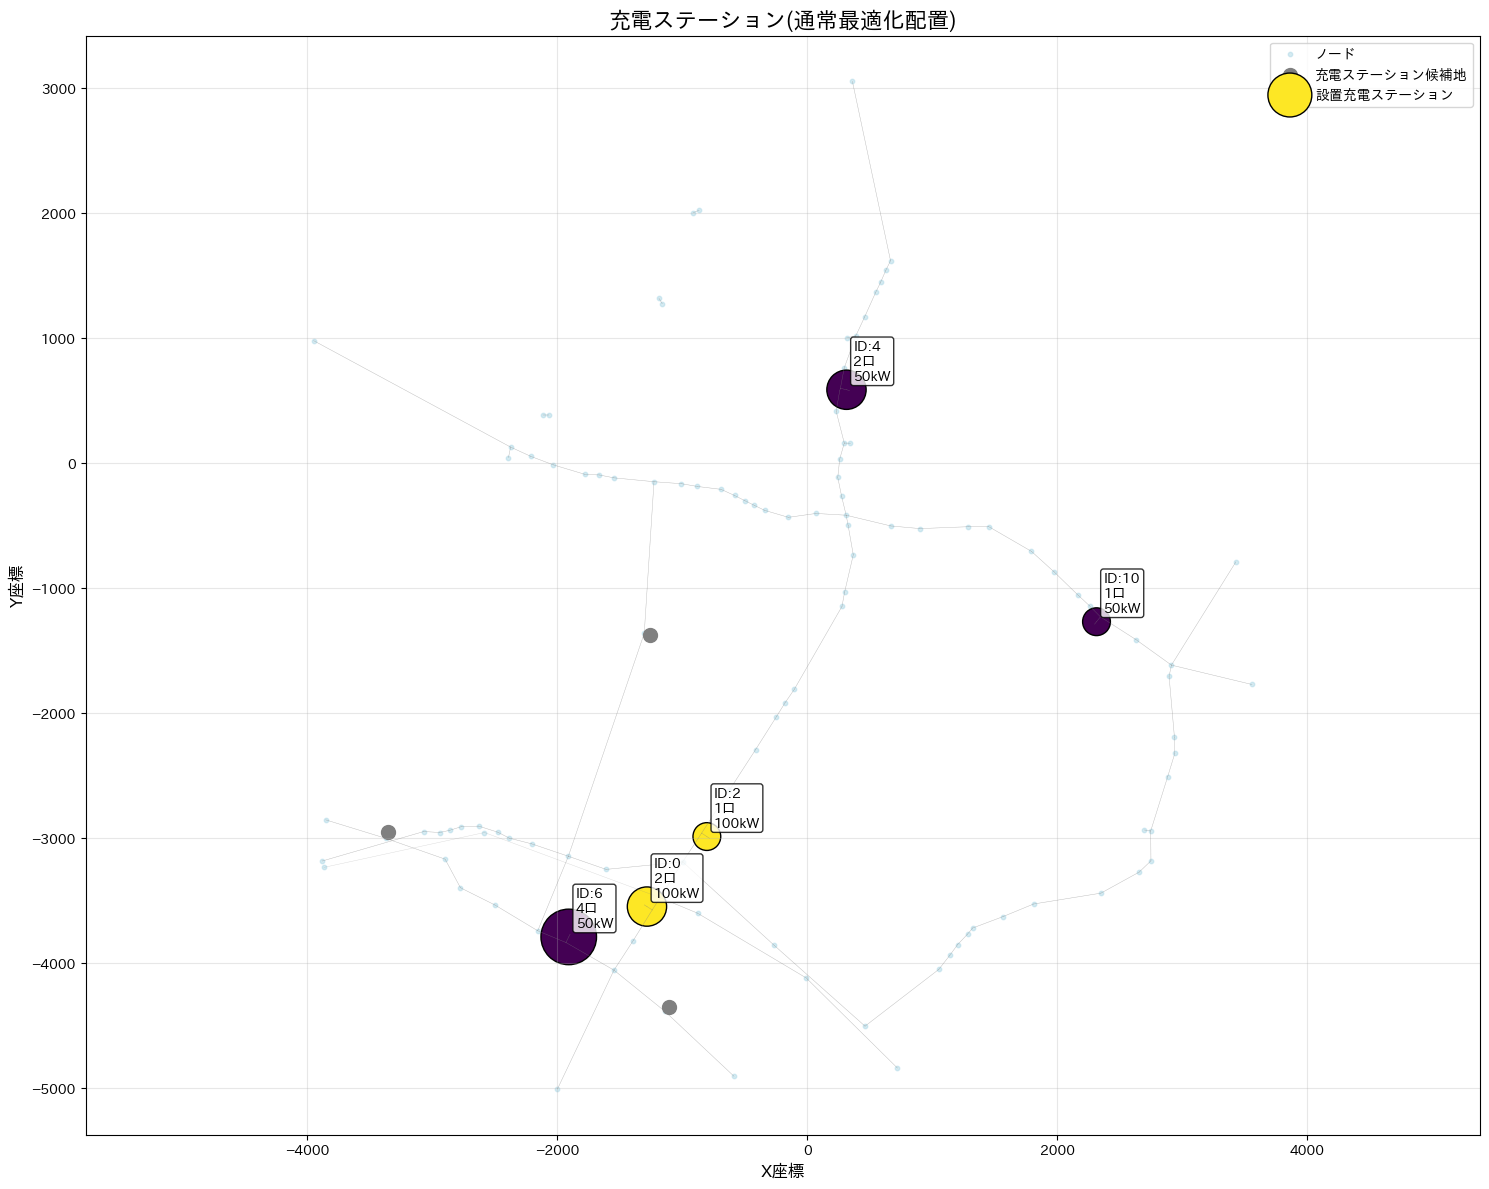

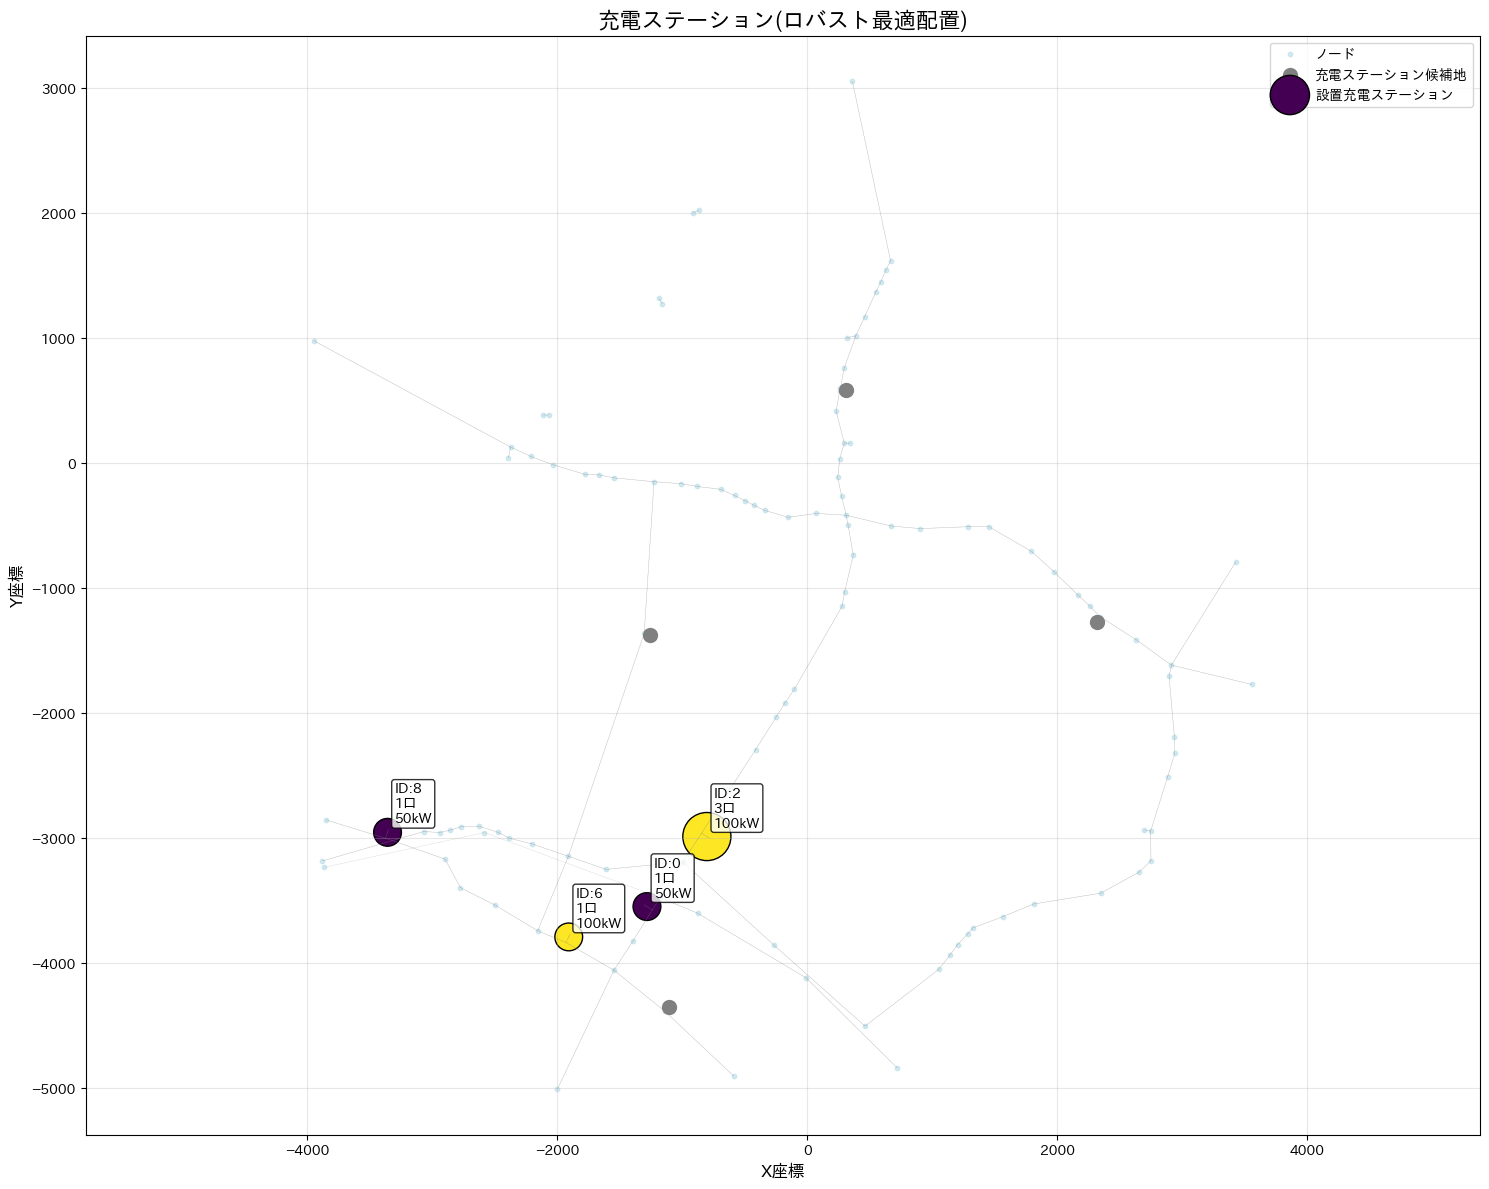

In [3]:
plt.figure(figsize=(15, 12))
plot_network_structure(result_path=f'{normal_save_dir}/{best_normal}', title='充電ステーション(通常最適化配置)')
plt.figure(figsize=(15, 12))
plot_network_structure(result_path=f'{failure_save_dir}/{best_robust_failure}', title='充電ステーション(ロバスト最適配置)')

##### 2.1:コスト（初期コスト，運用，総旅行時間）

Processing 14 files sequentially...


Processing files: 100%|██████████| 14/14 [00:00<00:00, 210.09it/s]

Successfully processed 14 files


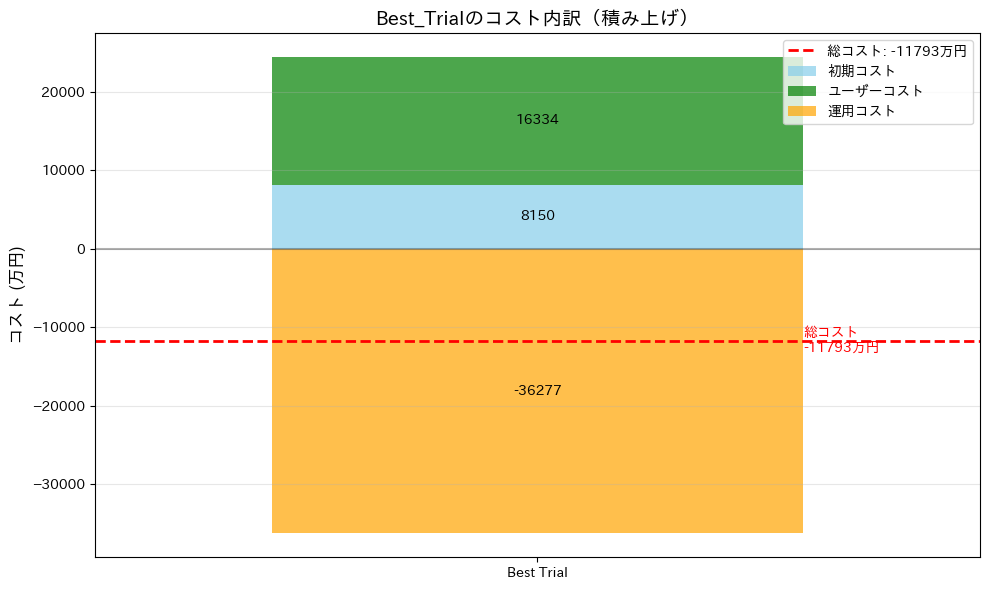

Processing 1 files sequentially...


Processing files: 100%|██████████| 1/1 [00:00<00:00, 121.73it/s]

Successfully processed 1 files


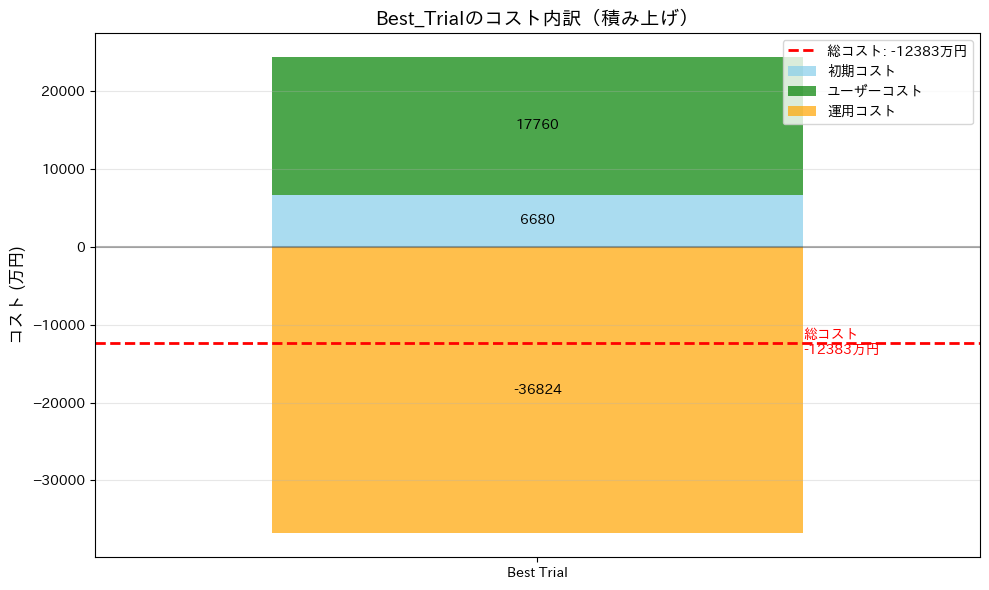

In [4]:
cost_df = crt_cost_df(normal_save_dir)
cost_df['total_cost'] = cost_df['initial_cost'] + cost_df['operational_cost'] + cost_df['user_cost']
best_cost_df = cost_df[cost_df['total_cost'] == cost_df['total_cost'].min()]
plot_costs(best_cost_df.iloc[0])

robust_cost_df = crt_cost_df(failure_save_dir)
robust_cost_df['total_cost'] = robust_cost_df['initial_cost'] + robust_cost_df['operational_cost'] + robust_cost_df['user_cost']
best_robust_cost_df = robust_cost_df[robust_cost_df['total_cost'] == robust_cost_df['total_cost'].min()]
plot_costs(best_robust_cost_df.iloc[0])

##### 2.2:待ち時間

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plot_waiting_times(result_file=f"{normal_save_dir}/{best_normal}", title="通常最適化配置での待ち時間(健常時)")
plt.subplot(2, 1, 2)
plot_waiting_times(result_file=f"{normal_save_dir}/{best_normal_failure}", title="通常最適化配置での待ち時間(故障時)")
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plot_waiting_times(result_file=f"{failure_save_dir}/{best_robust}", title="ロバスト最適配置での待ち時間(健常時)")
plt.subplot(2, 1, 2)
plot_waiting_times(result_file=f"{failure_save_dir}/{best_robust_failure}", title="ロバスト最適配置での待ち時間(故障時)")

##### 2.3:総旅行時間,総充電需要，初期コスト，総待ち時間，95パーセンタイル待ち時間の比較

In [10]:
def get_initial_cost(result_path):
    if result_path:
        with open(result_path, 'rb') as f:
            data = pickle.load(f)
        cs_config = data['cs_config']
        time_series_kw = data['time_series_kw']
        initial_cost = calc_initial_costs(cs_config, time_series_kw)
        return initial_cost
    return 0

def aggregate_results(result_file):
    initial_cost = get_initial_cost(result_file)
    waiting_times = get_waiting_times(result_file)
    total_waiting_times = sum(waiting_times)
    waiting_times_95 = np.percentile(waiting_times, 95)
    demand = get_total_kw(result_file)
    with open(result_file, 'rb') as f:
        data = pickle.load(f)
        vehicle_trip = data['vehicle_trip']
    total_trip_time_normal, _ = calc_diff_trnsprt_costs(vehicle_trip=vehicle_trip)
    return {
        "InitialCost": initial_cost,
        "TotalDemand": demand,
        "WaitingTimes": total_waiting_times,
        "95percentileWait": waiting_times_95,
        "TotalTripTime": total_trip_time_normal
    }
# 通常最適化＿健常時
result_file = f"{normal_save_dir}/{best_normal}"
normal_results = aggregate_results(result_file)
# 通常最適化＿故障時
# result_file = f"{normal_save_dir}/{best_normal_failure}"
# normal_results_failure = aggregate_results(result_file)
# ロバスト最適化＿健常時
# result_file = f"{failure_save_dir}/{best_robust}"
# robust_results = aggregate_results(result_file)
# ロバスト最適化＿故障時
result_file = f"{failure_save_dir}/{best_robust_failure}"
robust_results_failure = aggregate_results(result_file)


_ = 'dummy'
df = pd.DataFrame({
    "Case": ["Normal","Normal_failure", "Robust", "Robust_failure"],
    "InitialCost": [normal_results["InitialCost"], normal_results_failure["InitialCost"], robust_results["InitialCost"], robust_results_failure["InitialCost"]],
    "TotalDemand": [normal_results["TotalDemand"], normal_results_failure["TotalDemand"], robust_results["TotalDemand"], robust_results_failure["TotalDemand"]],
    "WaitingTimes": [normal_results["WaitingTimes"], normal_results_failure["WaitingTimes"], robust_results["WaitingTimes"], robust_results_failure["WaitingTimes"]],
    "95percentileWait": [normal_results["95percentileWait"], normal_results_failure["95percentileWait"], robust_results["95percentileWait"], robust_results_failure["95percentileWait"]],
    "TotalTripTime": [normal_results["TotalTripTime"], normal_results_failure["TotalTripTime"], robust_results["TotalTripTime"], robust_results_failure["TotalTripTime"]]
})
df.set_index("Case", inplace=True)
df.head()

NameError: name 'normal_results_failure' is not defined

### ロバスト配置で同様の評価


### 全ドライバーの総旅行時間（ガソリン車も含まれる。）

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
def load_vehicle_trip(result_dir: Path) -> pd.DataFrame:
    """走行データの読み込み"""
    vehicle_trip_path = result_dir / "vehicleTrip.txt"
    if not vehicle_trip_path.exists():
        return pd.DataFrame()
    
    df = pd.read_csv(
        vehicle_trip_path, sep=r',',usecols=[0, 2, 3, 4, 5, 8,9,10,11, 14],
        names=['EVID','StartTime', 'EndTime', 'WaitingEntryTime','startChargingTime',
                'startID','goalID','tripLength','CSID', 'InitialSOC'],
        dtype=str
    )
            # 特殊文字の処理
    def clean_numeric_value(value):
        """数値変換前の前処理"""
        if pd.isna(value) or value == '' or value == '******':
            return np.nan
        try:
            return float(value)
        except (ValueError, TypeError):
            return np.nan
    
    # 各列を適切な型に変換
    numeric_columns = ['EVID', 'StartTime', 'EndTime', 'WaitingEntryTime', 
                    'startChargingTime', 'startID', 'goalID', 'tripLength', 
                    'CSID', 'InitialSOC']
    
    for col in numeric_columns:
        if col in df.columns:
            df[col] = df[col].apply(clean_numeric_value)
    
    # 時間をmsから秒に変換
    time_cols = ['StartTime', 'EndTime', 'WaitingEntryTime', 'startChargingTime']
    for col in time_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce') / 1000
    
    return df

result_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\result'
vehicle_trip = load_vehicle_trip(Path(result_path))
vehicle_trip.head()

is_gas = vehicle_trip['InitialSOC'].isna()
gasoline_car = vehicle_trip[is_gas]
ev_car = vehicle_trip[~is_gas]
print(f"ガソリン車の数: {len(gasoline_car)}")
print(f"EV車両の数: {len(ev_car)}")

# 全ドライバーの総旅行時間
total_trip_time = vehicle_trip['EndTime'] - vehicle_trip['StartTime']
total_trip_time = total_trip_time.sum() / 3600  # 分単位に変換
print(f"全ドライバーの総旅行時間: {total_trip_time:.2f} 時間")

RESULT_PATH_NOCS = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\result\no_charging_station'
vehicle_trip_noCS = load_vehicle_trip(Path(RESULT_PATH_NOCS))
vehicle_trip_noCS.head()

is_gas = vehicle_trip_noCS['InitialSOC'].isna()
gasoline_car = vehicle_trip_noCS[is_gas]
ev_car = vehicle_trip_noCS[~is_gas]
print(f"ガソリン車の数: {len(gasoline_car)}")
print(f"EV車両の数: {len(ev_car)}")

# 全ドライバーの総旅行時間（充電なし）
total_trip_time_noCS = vehicle_trip_noCS['EndTime'] - vehicle_trip_noCS['StartTime']
total_trip_time_noCS = total_trip_time_noCS.sum() / 3600  # 分単位に変換
print(f"全ドライバーの総旅行時間: {total_trip_time_noCS:.2f} 時間")

total_trip_time_diff = total_trip_time - total_trip_time_noCS
print(f"充電ありと充電なしの総旅行時間の差: {total_trip_time_diff:.2f} 時間")
transportation_cost = total_trip_time_diff * 1118  # 時間あたりの価値を掛ける
print(f"総交通コストの差: {transportation_cost*365*5/10000:.2f} 万円")


In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
def load_vehicle_trip(result_dir: Path) -> pd.DataFrame:
    """走行データの読み込み"""
    vehicle_trip_path = result_dir / "vehicleTrip.txt"
    if not vehicle_trip_path.exists():
        return pd.DataFrame()
    
    df = pd.read_csv(
        vehicle_trip_path, sep=r',',usecols=[0, 2, 3, 4, 5, 8,9,10,11, 14],
        names=['EVID','StartTime', 'EndTime', 'WaitingEntryTime','startChargingTime',
                'startID','goalID','tripLength','CSID', 'InitialSOC'],
        dtype=str
    )
            # 特殊文字の処理
    def clean_numeric_value(value):
        """数値変換前の前処理"""
        if pd.isna(value) or value == '' or value == '******':
            return np.nan
        try:
            return float(value)
        except (ValueError, TypeError):
            return np.nan
    
    # 各列を適切な型に変換
    numeric_columns = ['EVID', 'StartTime', 'EndTime', 'WaitingEntryTime', 
                    'startChargingTime', 'startID', 'goalID', 'tripLength', 
                    'CSID', 'InitialSOC']
    
    for col in numeric_columns:
        if col in df.columns:
            df[col] = df[col].apply(clean_numeric_value)
    
    # 時間をmsから秒に変換
    time_cols = ['StartTime', 'EndTime', 'WaitingEntryTime', 'startChargingTime']
    for col in time_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce') / 1000
    
    return df

result_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\result'
vehicle_trip = load_vehicle_trip(Path(result_path))

# 全ドライバーの総旅行時間
total_trip_time = vehicle_trip['EndTime'].fillna(86400) - vehicle_trip['StartTime']
is_non_completed = total_trip_time.isna()
print(f"未完了の旅行時間の数: {is_non_completed.sum()}")

total_trip_time = total_trip_time.sum() / 3600  # 分単位に変換
print(f"全ドライバーの総旅行時間: {total_trip_time:.2f} 時間")

RESULT_PATH_NOCS = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\result\no_charging_station'
vehicle_trip_noCS = load_vehicle_trip(Path(RESULT_PATH_NOCS))
# 全ドライバーの総旅行時間（充電なし）
total_trip_time_noCS = vehicle_trip_noCS['EndTime'].fillna(86400) - vehicle_trip_noCS['StartTime']
total_trip_time_noCS = total_trip_time_noCS.sum() / 3600  # 分単位に変換

total_trip_time_diff = total_trip_time - total_trip_time_noCS
print(f"充電ありと充電なしの総旅行時間の差: {total_trip_time_diff:.2f} 時間")
transportation_cost = total_trip_time_diff * 1118  # 時間あたりの価値を掛ける
print(f"総交通コストの差: {transportation_cost*365*5/10000:.2f} 万円")

### 通常最適化とロバスト最適化配置の違い図示
- 故障時，健常時の指標を示し，ロバスト配置では故障のパフォーマンスが～の面からみてn%ほど良く，一方で通常最適化と比較して健常時のパフォーマンスは～の面から低下する，，，のようなことを示す。

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import japanize_matplotlib
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'IPAexGothic'

def plot_network_structure(result_path:Path, title= '充電ステーション候補地'):
    # データの読み込み
    map_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\mapPosition.txt'
    map_df = pd.read_csv(map_path, sep=',', header=None, names=['ID', 'X', 'Y', 'Z'])

    network_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\network.txt'
    network_df = pd.read_csv(network_path, sep=',', header=None, names=['from', 'link', 'to_1', 'to_2', 'to_3', 'to_4'])
    
    cslist_path = r'\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\csList.txt'
    cslist_df = pd.read_csv(cslist_path, sep=',', header=None, names=['ID', 'port', 'kw'])
    
    # ネットワーク図の可視化
    plt.figure(figsize=(15, 12))

    # ノードの描画
    plt.scatter(map_df['X'], map_df['Y'], c='lightblue', s=10, alpha=0.5, label='ノード')

    # リンクの描画
    for _, row in network_df.iterrows():
        from_node = map_df[map_df['ID'] == row['from']]
        
        # to_1からto_4までの接続先を描画
        for to_col in ['to_1', 'to_2', 'to_3', 'to_4']:
            if pd.notna(row[to_col]) and row[to_col] != 0:
                to_node = map_df[map_df['ID'] == row[to_col]]
                
                if not from_node.empty and not to_node.empty:
                    plt.plot([from_node['X'].iloc[0], to_node['X'].iloc[0]], 
                            [from_node['Y'].iloc[0], to_node['Y'].iloc[0]], 
                            'gray', alpha=0.3, linewidth=0.3)

    # 充電ステーション候補地を表示
    csids = cslist_df['ID']
    charging_stations = map_df[map_df['ID'].isin(csids)]
    plt.scatter(charging_stations['X'], charging_stations['Y'], c='gray', 
               s=100, label='充電ステーション候補地')
    
    def _plot_charging_stations(result_path, title, map_df):
    # 充電ステーションの実際の配置を表示（Optunaで採用された配置）
    
        if result_path:
            with open(result_path, 'rb') as f:
                data = pickle.load(f)
            cs_config = data['cs_config']
            
            # 充電ステーション設定データフレーム作成
            cs_df = pd.DataFrame({
                'csids': cs_config['csids'],
                'ports': cs_config['ports'],
                'cap_kw': cs_config['cap_kw']
            })
            
            # ポート数が0より大きい充電ステーションのみを表示
            setting_cs = cs_df[cs_df['ports'] > 0]
            
            if len(setting_cs) > 0:
                # 座標情報をマージ
                setting_cs_with_pos = pd.merge(setting_cs, map_df, 
                                            left_on='csids', right_on='ID', how='inner')
                
                # カラーマップの設定（充電出力用）
                from matplotlib import cm
                colors = setting_cs_with_pos['cap_kw']
                sizes = setting_cs_with_pos['ports'] * 400  # ポート数をサイズに変換（100倍で見やすく）

                # 離散値でのカラーマッピング
                unique_kw = sorted(setting_cs_with_pos['cap_kw'].unique())
                colors_discrete = plt.cm.viridis(np.linspace(0, 1, len(unique_kw)))
                color_map = {kw: colors_discrete[i] for i, kw in enumerate(unique_kw)}
                colors = [color_map[kw] for kw in setting_cs_with_pos['cap_kw']]
                
                # 散布図の作成（離散色で）
                scatter = plt.scatter(setting_cs_with_pos['X'], setting_cs_with_pos['Y'], 
                                    c=colors, s=sizes, alpha=1.0, 
                                    edgecolors='black', linewidths=1, label='設置充電ステーション')
                
                # 離散カラーバーの作成
                import matplotlib.patches as mpatches
                legend_elements = [mpatches.Patch(color=color_map[kw], label=f'{kw}kW') 
                                for kw in unique_kw]
                plt.legend(handles=legend_elements, loc='upper left', title='充電出力')
                
                # 充電ステーション情報を表示
                for _, row in setting_cs_with_pos.iterrows():
                    plt.annotate(f'ID:{int(row["csids"]) % 900000}\n{int(row["ports"])}口\n{int(row["cap_kw"])}kW', 
                            (row['X'], row['Y']), 
                            xytext=(5, 5), textcoords='offset points',
                            fontsize=10, ha='left', va='bottom',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

        plt.title(title, fontsize=16)
        plt.xlabel('X座標', fontsize=12)
        plt.ylabel('Y座標', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right')
        
        plt.axis('equal')
        plt.tight_layout()
        plt.show()

    _plot_charging_stations(result_path, title, map_df)
# 実行
import optuna
import optuna.visualization as vis


#### 1.故障を考慮しない最適化配置

In [ ]:
# 実行
import optuna
import optuna.visualization as vis
# 二時間故障
STUDY_NAME = "cs_optimization"
SAVE_DIR = '../20250815_0955'
STORAGE_URL = f"sqlite:///{SAVE_DIR}/optuna_study.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
# 最適化推移の可視化
fig = vis.plot_optimization_history(study)
fig.show()
plot_network_structure(result_path=f'{SAVE_DIR}/trial_165.pkl', title='充電ステーション(通常最適化配置)')



#### 1.1故障パターンをシミュレート（一回限り）

In [ ]:
import sys
import os
from datetime import datetime
import json
import pickle
import numpy as np
import pandas as pd
import optuna
from tqdm import tqdm
import matplotlib.pyplot as plt
import japanize_matplotlib
import shutil
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# プロジェクトのルートディレクトリをパスに追加
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
    
from src.simulation.run_emates import only_run_emates
from src.simulation.data_load import save_data_to_pickle
from src.util.path_manager import get_paths
from src.util.optimization import *

import concurrent.futures
import threading
import time
from src.simulation.create_emates_env import prepare_parallel_environment

current_time = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = current_time
os.makedirs(SAVE_DIR, exist_ok=True)
FAILURE_FLAG = True
FAILURE_TIME = [15]
def create_failure_scenario_parallel(cs_config: dict, trial, max_workers=None):
    """故障シナリオを並列で処理する統合関数"""
    
    # 1. 設置されているCSのインデックスを取得
    installed_cs_indices = [i for i, ports in enumerate(cs_config['ports']) if ports > 0]
    
    if len(installed_cs_indices) == 0:
        return float('inf'), float('inf')
    
    print(f"\n=== Trial {trial.number}: 故障シナリオ並列処理開始 ===")
    print(f"設置CS数: {len(installed_cs_indices)}, 並列シナリオ数: {len(installed_cs_indices)}")
    
    # 2. 並列数を決定（故障シナリオ数と同じ）
    parallel_count = len(installed_cs_indices)
    if max_workers:
        parallel_count = min(parallel_count, max_workers)
    
    # 3. 並列環境を構築（各ワーカーフォルダを作成）
    print("並列環境構築中...")
    prepare_parallel_environment(cs_config, parallel_count)
    print(f"✓ {parallel_count}個のワーカー環境を構築完了")
    
    # 4. 各故障シナリオを並列で実行
    start_time = time.time()
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=parallel_count) as executor:
        # 各故障シナリオのタスクを投入
        future_to_scenario = {}
        
        for worker_id, failure_cs_idx in enumerate(installed_cs_indices, 1):
            future = executor.submit(
                process_single_failure_scenario_with_worker,
                cs_config, failure_cs_idx, trial.number, SAVE_DIR, worker_id
            )
            future_to_scenario[future] = failure_cs_idx
            # print(f"故障シナリオCS{failure_cs_idx} → Worker{worker_id}に投入")
        
        # 結果を順次収集
        results = []
        completed = 0
        
        for future in concurrent.futures.as_completed(future_to_scenario):
            failure_cs_idx = future_to_scenario[future]
            
            try:
                result = future.result(timeout=3600)  # 1時間タイムアウト
                results.append(result)
                completed += 1
                
                print(f"✓ [{completed}/{len(installed_cs_indices)}] "
                      f"故障CS{failure_cs_idx}完了: "
                      f"コスト={result['cost']:.2f}万円, "
                      f"95%待ち時間={result['wait_time_95p']:.2f}秒")
                
            except concurrent.futures.TimeoutError:
                print(f"❌ 故障CS{failure_cs_idx}がタイムアウト")
                results.append({
                    'failure_cs_idx': failure_cs_idx,
                    'cost': float('inf'),
                    'wait_time_95p': float('inf'),
                    'error': 'timeout'
                })
            except Exception as e:
                print(f"❌ 故障CS{failure_cs_idx}でエラー: {e}")
                results.append({
                    'failure_cs_idx': failure_cs_idx,
                    'cost': float('inf'),
                    'wait_time_95p': float('inf'),
                    'error': str(e)
                })
    
    end_time = time.time()
    print(f"\n並列処理完了（{end_time - start_time:.2f}秒）")
    
    # 5. 結果の集計
    valid_results = [r for r in results if r['cost'] != float('inf')]
    
    if not valid_results:
        print("❌ 有効な結果がありません")
        return float('inf')
    
    # 最悪ケースの抽出
    worst_cost = max(r['cost'] for r in valid_results)
    worst_wait_time = max(r['wait_time_95p'] for r in valid_results)
    
    print(f"📊 結果サマリー:")
    print(f"  有効シナリオ数: {len(valid_results)}/{len(results)}")
    print(f"  最悪ケースコスト: {worst_cost:.2f}万円")
    print(f"  最悪ケース95%待ち時間: {worst_wait_time:.2f}秒")
    # ワーストケース以外を削除
    for result in results:
        if result['cost'] != worst_cost:
            # 該当ワーカーの結果ファイルを削除
            if 'results_filepath' in result:
                try:
                    os.remove(result['results_filepath'])
                    print(f"削除: {result['results_filepath']}")
                except Exception as e:
                    print(f"削除失敗: {result['results_filepath']} - {e}")

    return worst_cost

def process_single_failure_scenario_with_worker(cs_config, failure_cs_idx, trial_number, save_dir, worker_id):
    """指定されたワーカーで単一の故障シナリオを処理"""
    
    try:
        
        # 1. 指定されたワーカー用に故障情報を作成
        create_failure_info_for_worker(cs_config, failure_cs_idx, worker_id, FAILURE_TIME=FAILURE_TIME)
        
        # 2. 該当ワーカーでシミュレーション実行（単一ワーカーのみ）
        only_run_emates(worker_id=worker_id)
        
        # 3. 結果の保存
        results_filename = f"trial_{trial_number}_worker_{worker_id}.pkl"
        results_filepath = os.path.join(save_dir, results_filename)
        save_data_to_pickle(worker_id=worker_id, filename=results_filepath)
        
        # 4. コスト計算
        eval_costs, _ = evaluation_total_costs(results_filepath)
        
        
        # 5. 95パーセンタイル待ち時間計算
        wait_time_95p = calculate_95percentile_wait_time(results_filepath)
        
        return {
            'failure_cs_idx': failure_cs_idx,
            'worker_id': worker_id,
            'cost': eval_costs,
            'wait_time_95p': wait_time_95p,
            'results_filepath': results_filepath
        }
        
    except Exception as e:
        print(f"❌ Worker{worker_id}で故障CS{failure_cs_idx}の処理中にエラー: {e}")
        return {
            'failure_cs_idx': failure_cs_idx,
            'worker_id': worker_id,
            'cost': float('inf'),
            'wait_time_95p': float('inf'),
            'error': str(e)
        }

# 並列処理版の目的関数
def cs_placement_objective_failure_parallel(trial) -> tuple:
    """並列処理版：故障時のみを考慮した多目的最適化の目的関数"""
    
    # 1. OptunaによるCS配置の提案
    cs_config = set_cs_placement(trial, worker_id=1)
    
    # 2. CS配置の妥当性チェック
    if not check_cs_placement(cs_config):
        print("CS配置が不適切です。最低2箇所の充電ステーションを設置してください。")
        return float('inf')
    
    # 3. 並列故障シナリオ実行
    worst_failure_cost = create_failure_scenario_parallel(
        cs_config, trial, max_workers=8  # 最大4並列に制限
    )
    
    return worst_failure_cost

def manage_pkl_files_after_optimization(study, save_dir):
    """最適化完了後のpklファイル管理"""
    print("\n=== 最適化完了後のファイル管理 ===")
    
    save_path = Path(save_dir)
    pkl_files = [f for f in os.listdir(save_path) if f.endswith('.pkl')]
    
    if not pkl_files:
        print("pklファイルが見つかりません。")
        return
    
    # ベストtrialを特定
    best_trial_number = study.best_trial.number
    print(f"ベストtrial: {best_trial_number}")
    
    # 保持するファイルを選定
    trials_to_keep = set()
    
    # 1. ベストtrial
    best_file = f"trial_{best_trial_number}.pkl"
    if best_file in pkl_files:
        trials_to_keep.add(best_file)
    
    # 2. 10の倍数のtrial
    for f in pkl_files:
        try:
            trial_num = int(f.split('_')[1].split('.')[0])
            if trial_num % 10 == 0:
                trials_to_keep.add(f)
        except (IndexError, ValueError):
            continue
    
    # 3. 最新10個のtrial
    try:
        sorted_files = sorted(pkl_files, 
                            key=lambda x: int(x.split('_')[1].split('.')[0]), 
                            reverse=True)
        for f in sorted_files[:10]:
            trials_to_keep.add(f)
    except (IndexError, ValueError):
        print("ファイル名の解析に失敗しました。")
    
    # 4. 削除対象を特定
    files_to_delete = set(pkl_files) - trials_to_keep
    
    # 統計情報を表示
    print(f"\n総ファイル数: {len(pkl_files)}")
    print(f"保持ファイル数: {len(trials_to_keep)}")
    print(f"削除対象ファイル数: {len(files_to_delete)}")
    
    if len(files_to_delete) == 0:
        print("削除対象のファイルはありません。")
        return
    
    # ファイルサイズの分析
    keep_size = 0
    delete_size = 0
    
    for file_name in trials_to_keep:
        file_path = save_path / file_name
        if file_path.exists():
            keep_size += file_path.stat().st_size
    
    for file_name in files_to_delete:
        file_path = save_path / file_name
        if file_path.exists():
            delete_size += file_path.stat().st_size
    
    print(f"保持データサイズ: {keep_size / (1024**2):.1f} MB")
    print(f"削除データサイズ: {delete_size / (1024**2):.1f} MB")
    print(f"削除による節約: {delete_size / (keep_size + delete_size) * 100:.1f}%")
    
    # 保持ファイルの内訳を表示
    print(f"\n=== 保持ファイル詳細 ===")
    for file in sorted(trials_to_keep):
        try:
            trial_num = int(file.split('_')[1].split('.')[0])
            file_path = save_path / file
            size_mb = file_path.stat().st_size / (1024**2) if file_path.exists() else 0
            
            reason = []
            if file == best_file:
                reason.append("ベスト")
            if trial_num % 10 == 0:
                reason.append("10の倍数")
            if file in sorted_files[:10]:
                reason.append("最新10個")
            
            print(f"  {file} (trial {trial_num}, {size_mb:.1f}MB) - {', '.join(reason)}")
        except (IndexError, ValueError):
            print(f"  {file} - ファイル名解析失敗")
    
    # 自動的にバックアップディレクトリに移動
    backup_dir = save_path / "backup_deleted_trials"
    backup_dir.mkdir(exist_ok=True)
    
    moved_count = 0
    for file_name in files_to_delete:
        file_path = save_path / file_name
        backup_path = backup_dir / file_name
        
        if file_path.exists():
            try:
                shutil.move(str(file_path), str(backup_path))
                moved_count += 1
            except Exception as e:
                print(f"ファイル移動失敗 {file_name}: {e}")
    
    print(f"\n{moved_count}個のファイルをバックアップディレクトリに移動しました。")
    print(f"バックアップ先: {backup_dir}")
    
    # 残りファイルサイズを確認
    remaining_size = sum(f.stat().st_size for f in save_path.glob("*.pkl")) / (1024**2)
    print(f"残りのpklファイルサイズ: {remaining_size:.1f} MB")

# 並列処理版の最適化実行
def run_optuna_failure_optimization_parallel(n_trials=150, timeout = 60*60*24):
    """並列処理版故障時最適化の実行"""
    db_path = os.path.join(SAVE_DIR, 'optuna_failure_study_parallel.db')
    db_url = f"sqlite:///{db_path}"
    study_name = "cs_failure_optimization_parallel"
    
    try:
        study = optuna.load_study(study_name=study_name, storage=db_url)
        print(f"既存の並列処理Studyを読み込みました（トライアル数: {len(study.trials)}）")
    except KeyError:
        study = optuna.create_study(
            directions=['minimize'],
            study_name=study_name, 
            storage=db_url
        )
        print("新しい並列処理Studyを作成しました")
    
    print(f"\n🚀 並列故障シナリオ最適化を開始します")
    print(f"トライアル数: {n_trials}")
    print(f"各トライアルで故障シナリオを並列実行します")
    
    # 最適化実行
    # ✅ --- tqdmによるプログレスバーのセットアップ ---
    with tqdm(total=n_trials, desc="Optimization Progress") as pbar:
        # 各トライアル完了時にプログレスバーを更新するコールバック関数
        def progress_bar_callback(study, trial):
            pbar.update(1)
        study.optimize(cs_placement_objective_failure_parallel, n_trials=n_trials,
                       callbacks=[progress_bar_callback], timeout=timeout)
    # ✅ --- プログレスバーのセットアップここまで ---
    manage_pkl_files_after_optimization(study, SAVE_DIR)

In [ ]:
# run_optuna_failure_optimization_parallel(n_trials=1, timeout=60*60*24)
# 最小コストの故障シナリオを取得
SAVE_DIR = '20250818_1745'
STUDY_NAME = "cs_failure_optimization_parallel"
# SAVE_DIR = '../20250815_0955'
STORAGE_URL = f"sqlite:///{SAVE_DIR}/optuna_failure_study_parallel.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
pkl_files = [f for f in os.listdir(SAVE_DIR) if f.endswith('.pkl')]
for pkl_file in pkl_files:
    with open(os.path.join(SAVE_DIR, pkl_file), 'rb') as f:
        emates_result = pickle.load(f)
plot_costs

#### 2.　1時間故障

In [ ]:
# 一時間故障
STUDY_NAME = "cs_failure_optimization_parallel"
SAVE_DIR = '20250815_1001_1hour_fail'
STORAGE_URL = f"sqlite:///{SAVE_DIR}/optuna_failure_study_parallel.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
# 最適化推移の可視化
fig = vis.plot_optimization_history(study)
fig.show()

plot_network_structure(result_path=f'{SAVE_DIR}/trial_95_failure_cs_0_worker_1.pkl', title='充電ステーション(一時間故障)')

##### 2.1　通常時のシミュレート

#### 3. 2時間故障

In [ ]:
# 二時間故障
STUDY_NAME = "cs_failure_14_15hour"

SAVE_DIR = '20250816_1051_2hour_fail'
STORAGE_URL = f"sqlite:///{SAVE_DIR}/optuna_failure_study_parallel.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
# 最適化推移の可視化
fig = vis.plot_optimization_history(study)
fig.show()
plot_network_structure(result_path=f'{SAVE_DIR}/trial_84_failure_cs_0_worker_1.pkl', title='充電ステーション(二時間故障)')